In [1]:
import numpy as np 
import datetime 

today = datetime.date.today()
timestamp = datetime.datetime.now().timestamp()


In [5]:
a = datetime.datetime.now()

In [2]:
today

datetime.date(2026, 4, 25)

In [6]:
str(a)

'2026-04-25 17:02:29.447765'

\begin{equation}
\Psi_{D2}(x, \mu) =
\frac{3\mu}{
\delta \left(
1 + \sqrt{1 + \frac{9\mu}{2\delta^2}}
\cosh\left(\sqrt{-2\mu}(x - x_0)\right)
\right)}
\end{equation}

In [2]:
# -----------------------------
# analytical solution
# -----------------------------
def droplet_analytical_solution(mu, delta, domain):
    """
    Generate analytical droplet solution ψ(x)

    Args:
        mu: chemical potential (must be < 0)
        delta: interaction parameter (≠ 0)
        x0: center of droplet
        N: number of grid points

    Returns:
        x: grid points
        psi: solution ψ(x)
    """
    
    if mu >= 0:
        raise ValueError("mu must be negative")
    if delta == 0:
        raise ValueError("delta cannot be zero")

    inside = 1 + (9 * mu) / (2 * delta**2)
    if inside < 0:
        print(f"invalid for the current parameters mu={mu} and delta ={delta}")
        return None, None  # skip invalid

    x = np.linspace(domain["x_a"], domain["x_b"], domain["N"])

    sqrt_term = np.sqrt(inside)
    k = np.sqrt(-2 * mu)
    cosh_term = np.cosh(k * (x - domain["x0"]))

    denom = delta * (1 + sqrt_term * cosh_term)
    psi = (3 * mu) / denom

    return x, psi



In [8]:
0.99**2000

1.863756602992233e-09

## Sampled solution 

In [18]:

mu_1 = -0.2222 
delta_1 = np.sqrt(-9 * mu_1/2) + 0.05
delta_2 = 1.1
 
mu_3 = -0.05
delta_3 = np.sqrt(-4.5 * mu_3) + 0.05
delta_4 = 1.1
 
physics_domain_params = {
    "x_a": -20,
    "x_b": 20, 
    "N": 4096, 
    "x0": 0
}
 

x_1, phi_1 = droplet_analytical_solution(
                mu_1, delta_1, physics_domain_params
            )
            
            
 
x_2, phi_2 = droplet_analytical_solution(
                mu_1, delta_2, physics_domain_params
            )
            
            
 
x_3, phi_3 = droplet_analytical_solution(
                mu_3, delta_3, physics_domain_params
            )
            
            
         
x_4, phi_4 = droplet_analytical_solution(
                mu_3, delta_4, physics_domain_params
            )
            

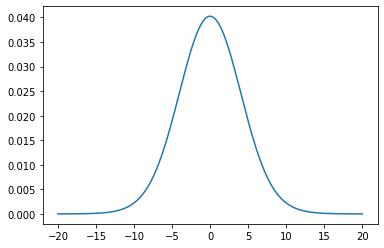

In [ ]:
plt.plot(x_3, phi_3**2, label = f'[$\mu$ = {mu_3}, $\delta$ ={delta_3}]')


---

import matplotlib.pyplot as plt 
plt.figure(figsize = (14, 8))

plt.plot(x_1, phi_1 **2, label = f'[$\mu$ = {mu_1}, $\delta$ ={delta_1}]')

plt.plot(x_1, phi_2**2, label = f'[$\mu$ = {mu_1},$\delta$ ={delta_2}]')
plt.plot(x_1, phi_3**2, label = f'[$\mu$ = {mu_3}, $\delta$ ={delta_3}]')

plt.plot(x_1, phi_4**2, label = f'[$\mu$ = {mu_3}, $\delta$ ={delta_4}]')
#plt.yticks(np.linspace(0,0.45, 10))
plt.legend()


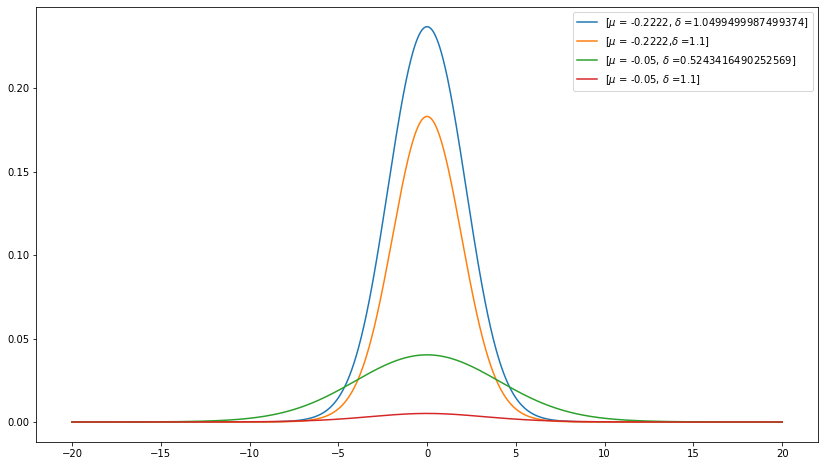

## Run the other parameters result 

In [20]:
mu_sets_params = {
        "mu_left": -0.2222,
        "mu_right": -0.05 ,
        "N_mu": 15 }

# -----------------------------
# build dataset
# -----------------------------
mu_list = np.linspace(
    mu_sets_params["mu_left"],
    mu_sets_params["mu_right"],
    mu_sets_params["N_mu"]
)

N_mu_list = 2 * np.arange(1, mu_sets_params["N_mu"]+1)


In [21]:

delta_func = lambda mu, n_delta: np.linspace(np.sqrt( -4.5 * mu) + 0.05,   1.1,  n_delta)

 
parameters_pairs = [ ]
for mu, n_delta in zip( mu_list, N_mu_list): 
    
    delta_ls = delta_func( mu, n_delta)


    for delta_i in  delta_ls: 
        parameters_pairs.append( [mu, delta_i])


In [22]:

for mu, delta in parameters_pairs:
    print(mu, delta)

-0.2222 1.0499499987499374
-0.2222 1.1
-0.2099 1.0218796221755038
-0.2099 1.0479197481170026
-0.2099 1.0739598740585012
-0.2099 1.1
-0.1976 0.9929740187301027
-0.1976 1.0143792149840822
-0.1976 1.0357844112380616
-0.1976 1.057189607492041
-0.1976 1.0785948037460207
-0.1976 1.1
-0.18530000000000002 0.9631538753134655
-0.18530000000000002 0.9827033216972562
-0.18530000000000002 1.002252768081047
-0.18530000000000002 1.0218022144648375
-0.18530000000000002 1.0413516608486282
-0.18530000000000002 1.0609011072324188
-0.18530000000000002 1.0804505536162095
-0.18530000000000002 1.1
-0.173 0.9323264701911645
-0.173 0.9509568623921463
-0.173 0.969587254593128
-0.173 0.9882176467941097
-0.173 1.0068480389950913
-0.173 1.0254784311960732
-0.173 1.044108823397055
-0.173 1.0627392155980366
-0.173 1.0813696077990183
-0.173 1.1
-0.1607 0.900382266983502
-0.1607 0.9185293336213655
-0.1607 0.9366764002592289
-0.1607 0.9548234668970924
-0.1607 0.9729705335349559
-0.1607 0.9911176001728192
-0.1607 1.0092

In [ ]:



phi_all = []
mu_all = []
delta_all = []

x_ref = None

phi_v = float('inf')

for mu, delta in parameters_pairs:

    x, phi = droplet_analytical_solution(
        mu, delta, physics_domain_params
    )
    phi_v = min( phi_v, min(-phi) )
    print( mu, delta, "***************", max(phi)) 

    if x is None:
        continue  # skip invalid combo

    if x_ref is None:
        x_ref = x  # store once

    phi_all.append(phi)
    mu_all.append(mu)
    delta_all.append(delta)

# convert to numpy
phi_all = np.array(phi_all)        # shape: (M, N)
mu_all = np.array(mu_all)          # shape: (M,)
delta_all = np.array(delta_all)    # shape: (M,)


-0.2222 1.0499499987499374 *************** -6.748943518555526e-06
-0.2222 1.1 *************** -4.713845514438918e-06
-0.2099 1.0218796221755038 *************** -9.398883773301903e-06
-0.2099 1.0479197481170026 *************** -7.57222063640179e-06
-0.2099 1.0739598740585012 *************** -6.493708759535171e-06
-0.2099 1.1 *************** -5.759814912850578e-06
-0.1976 0.9929740187301027 *************** -1.3201336394527842e-05
-0.1976 1.0143792149840822 *************** -1.0986305586315885e-05
-0.1976 1.0357844112380616 *************** -9.584233485342392e-06
-0.1976 1.057189607492041 *************** -8.593245952058266e-06
-0.1976 1.0785948037460207 *************** -7.84414766957705e-06
-0.1976 1.1 *************** -7.2516415386732665e-06
-0.18530000000000002 0.9631538753134655 *************** -1.8714275858253572e-05
-0.18530000000000002 0.9827033216972562 *************** -1.5785646698357112e-05
-0.18530000000000002 1.002252768081047 *************** -1.3875435866002872e-05
-0.18530000000

In [30]:
phi_v 

4.713845514438918e-06

In [ ]:

solution = {
    "mu": mu_all,
    "delta": delta_all,
    "x": x_ref,
    "phi": phi_all
}

sol_name = f"./data/solution_{today}_{timestamp}.npz"
np.savez(sol_name, **solution)

print("This data is generated based on the analytical solution.") 

In [ ]:
import h5py

with h5py.File(sol_name, "w") as f:
    # 共享的 x 轴存一次
    f.create_dataset("x", data=x_ref)
    
    # 每组参数单独成组
    for i, (mu, delta, phi) in enumerate(zip(mu_all, delta_all, phi_all)):
        grp = f.create_group(f"run_{i:04d}")
        grp.attrs["mu"] = mu        # 参数作为 attribute
        grp.attrs["delta"] = delta
        grp.create_dataset("phi", data=phi)

    # 全局 metadata
    f.attrs["description"] = "Analytical droplet solutions"
    f.attrs["created"] = str(today)

NameError: name 'x_ref' is not defined

In [47]:
solution['phi']

array([[-0.0001891 , -0.00019002, -0.00019095, ..., -0.00019095,
        -0.00019002, -0.0001891 ]])

In [53]:
data = np.load(sol_name,allow_pickle = True)
solution = {key: data[key] for key in data.files}

In [50]:
phi_all.shape

(240, 4096)

In [ ]:

np.datamu_all.shape


(240,)

NameError: name 'load_split' is not defined

In [9]:
with h5py.File(sol_name, "r") as f:
    x = f["x"][:]
    
    run_names = sorted([k for k in f.keys() if k != "x"])
    B = len(run_names)
    N = len(x)
    
    params = np.zeros((B, 2))      # (B, 2)  col0=mu, col1=delta
    phi_all = np.zeros((B, N))     # (B, 4096)
    
    for i, run_name in enumerate(run_names):
        grp = f[run_name]
        params[i, 0] = grp.attrs["mu"]
        params[i, 1] = grp.attrs["delta"]
        phi_all[i]   = grp["phi"][:]

print(params.shape)    # (B, 2)
print(phi_all.shape)   # (B, 4096)


KeyError: "Can't open attribute (can't locate attribute: 'mu')"

In [ ]:
data_loader = params
print(phi_all.shape) a

In [ ]:

# 取用时
mu_all    = params[:, 0]   # (B,)
delta_all = params[:, 1]   # (B,)

In [14]:
now  = datetime.datetime.now()
import torch.nn as nn
# %%
# ============================================================
# Config for data 
# ============================================================
RANDOM_SEED = 20260425

PHYSICS_DOMAIN = {
    "x_a": -20,
    "x_b":  20,
    "N":  4096,
    "x0":    0,
}

TRAIN_CONFIG = {
    "mu_left":  -0.2222,
    "mu_right": -0.05,
    "N_mu":      15,
}


TEST_CONFIG = {
    "mu_left":  -0.2222,
    "mu_right": -0.05,
    "delta_max":  1.1,
    "N_test":     120,       # 总随机采样数
    "seed":    RANDOM_SEED,
}

# %%
# ============================================================
# Config for  model and model training 
# ============================================================
config = {
    
    
    # Model parameters 
    "hidden_dims": [128, 128, 128], 
    "latent_feature_dim":16,
    "n_latent":64,
    "hidden_conv_dims": [256, 128, 64, 64, 32, 32],
    "activation":nn.ReLU,
    "output_activation": None, 
    "dropout": 0.1,
    
    
    # Training parameters 
    "epochs" : 5, 
    "epoch_save":1, 
    "batch_size": 32,
    "log_path":f"./logs/train_{config['eq_name']}_{now:%Y-%m-%d_%H%M%S}.log", 
    
    # Optimizer parameters 
    "learning_rate": 1e-3,
    "step_size": 1,
    "weight_decay": 1e-5,
    "gamma":0.99, 


    # data
    "input_dim": 2,
    "output_sol_dim": 1, 
    "eq_name": "Ex1",
    

} 


NameError: name 'config' is not defined

In [15]:




 
# %%
# ============================================================
# Build train / test
# ============================================================
train_pairs = build_train_pairs(TRAIN_CONFIG)
test_pairs  = build_test_pairs(TEST_CONFIG)

print(f"Train pairs : {len(train_pairs)}")
print(f"Test  pairs : {len(test_pairs)}")

train_data = build_dataset(train_pairs, PHYSICS_DOMAIN)
test_data  = build_dataset(test_pairs,  PHYSICS_DOMAIN)

print(f"\nTrain phi shape : {train_data['phi'].shape}")
print(f"Test  phi shape : {test_data['phi'].shape}")



Train pairs : 240
Test  pairs : 120

Train phi shape : (240, 4096)
Test  phi shape : (120, 4096)


In [61]:
sol_name = f"../data/solution_Ex1.h5"
def plot_results(x, params, phi_pred, phi_true,
                 indices=None, save_path=None):
    """
    Plot 4 samples: prediction vs ground truth.

    Args:
        x          : (N,)   spatial grid
        params     : (M, 2) [mu, delta]
        phi_pred   : (M, N)
        phi_true   : (M, N)
  
        indices    : list of 4 indices to plot (default: spread across dataset)
        save_path  : if given, saves figure
    """
    if indices is None:
        M = phi_pred.shape[0]
        indices = [0, M // 3, 2 * M // 3, M - 1]
        print (indices)

    # ── style ────────────────────────────────────────────────
    plt.rcParams.update({
        "font.family":      "serif",
        "font.size":         11,
        "axes.labelsize":    12,
        "axes.titlesize":    11,
        "legend.fontsize":    9,
        "xtick.labelsize":   10,
        "ytick.labelsize":   10,
        "axes.linewidth":     0.8,
        "lines.linewidth":    1.8,
    })

    colors = ["#2166ac", "#d6604d", "#4dac26", "#7b3294"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    axes = axes.flatten()

    
    for ax, idx, color in zip(axes, indices, colors):
        print(  zip(axes, indices, colors), )
        print(  params[idx, 0], idx, " ---- ")
        mu    = params[idx, 0]
        delta = params[idx, 1]
     

        # plot |ψ|²
        ax.plot(x, phi_true[idx]**2, color=color,
                linestyle="-",  label="Analytical",  linewidth=1.8)
        ax.plot(x, phi_pred[idx]**2, color="k",
                linestyle="--", label="Surrogate",   linewidth=1.4, alpha=0.85)

        ax.set_title(
            rf"$\mu={mu:.4f},\ \delta={delta:.3f}$"
            f"\n",
            pad=6
        )
        ax.set_xlim(x[0], x[-1])
        ax.set_ylim(bottom=0)
        ax.legend(frameon=False)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$|\Psi|^2$")

    fig.suptitle(r"Surrogate vs Analytical Droplet Solution $|\phi_{D2}|^2$",
                 fontsize=13, y=1.01)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved → {save_path}")

    plt.show()

In [59]:
params

array([[-0.11621447,  0.9599885 ],
       [-0.1652968 ,  0.99916966],
       [-0.10295112,  1.03896722],
       [-0.20837279,  1.04495958],
       [-0.14808594,  0.89738471],
       [-0.05293048,  0.99161722],
       [-0.11349264,  1.01477615],
       [-0.12090643,  0.96402875],
       [-0.05208176,  0.78468368],
       [-0.15535507,  1.07489133],
       [-0.21729786,  1.08937743],
       [-0.21838613,  1.04683746],
       [-0.13171839,  0.92354951],
       [-0.21927747,  1.05972243],
       [-0.15382576,  1.03993831],
       [-0.13597711,  0.94486821],
       [-0.08938714,  1.00169607],
       [-0.20437905,  1.06705956],
       [-0.1365384 ,  1.02229842],
       [-0.11823197,  0.93226223],
       [-0.15741152,  0.9214165 ],
       [-0.09446544,  0.77969834],
       [-0.2169905 ,  1.05531815],
       [-0.0694576 ,  1.08371468],
       [-0.20303766,  1.09145755],
       [-0.07832001,  1.0646382 ],
       [-0.06643112,  1.07258534],
       [-0.15394387,  1.09120995],
       [-0.17715057,

In [56]:
print(test_data['x'].shape, params.shape, test_data['phi'].shape, test_data['phi'].shape, )

(4096,) (2, 2) (120, 4096) (120, 4096)


In [94]:
 params_all

array([[-0.11621447,  0.9599885 ],
       [-0.1652968 ,  0.99916965],
       [-0.10295112,  1.0389673 ],
       [-0.20837279,  1.0449595 ],
       [-0.14808594,  0.8973847 ],
       [-0.05293048,  0.9916172 ],
       [-0.11349264,  1.0147761 ],
       [-0.12090643,  0.9640288 ],
       [-0.05208176,  0.7846837 ],
       [-0.15535507,  1.0748913 ],
       [-0.21729787,  1.0893774 ],
       [-0.21838613,  1.0468374 ],
       [-0.13171838,  0.92354953],
       [-0.21927747,  1.0597224 ],
       [-0.15382576,  1.0399383 ],
       [-0.13597712,  0.9448682 ],
       [-0.08938714,  1.0016961 ],
       [-0.20437905,  1.0670595 ],
       [-0.1365384 ,  1.0222985 ],
       [-0.11823197,  0.93226224],
       [-0.15741152,  0.9214165 ],
       [-0.09446544,  0.7796983 ],
       [-0.2169905 ,  1.0553181 ],
       [-0.0694576 ,  1.0837147 ],
       [-0.20303766,  1.0914576 ],
       [-0.07832   ,  1.0646383 ],
       [-0.06643112,  1.0725853 ],
       [-0.15394388,  1.09121   ],
       [-0.17715058,

[0, 40, 80, 119]
-0.11621446537859341 0  ---- 
-0.10867019327763462 40  ---- 
-0.06690882093395101 80  ---- 
-0.1264170434897543 119  ---- 


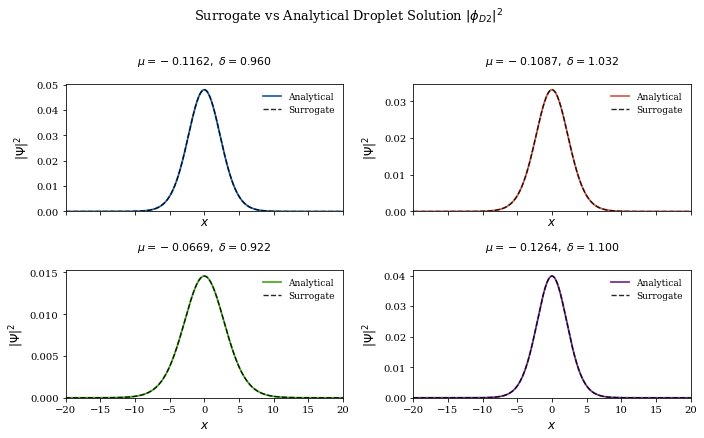

In [62]:
import matplotlib.pyplot as plt
plot_results(test_data['x'], params, test_data['phi'], test_data['phi'],
                 indices=None, save_path=None) 

In [69]:
def evaluate_model(models, test_loader, device):
    """
    Returns
        params_all : (M, 2)   [mu, delta]
        phi_pred   : (M, N)   model prediction
        phi_true   : (M, N)   ground truth
        rel_errors : (M,)     relative L2 error per sample
    """
    model1, model2 = models[0], models[1]
    criterion = nn.MSELoss()

    params_all, phi_pred_all, phi_true_all = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for params, phi in test_loader:
            params, phi = params.to(device), phi.to(device)

            pred = model2(model1(params)).squeeze(-1)   # (B, N)
            loss = criterion(pred, phi)
            total_loss += loss.item()

            params_all.append(params.cpu().numpy())
            phi_pred_all.append(pred.cpu().numpy())
            phi_true_all.append(phi.cpu().numpy())

    params_all  = np.concatenate(params_all,  axis=0)   # (M, 2)
    phi_pred    = np.concatenate(phi_pred_all, axis=0)   # (M, N)
    phi_true    = np.concatenate(phi_true_all, axis=0)   # (M, N)

    # relative L2 error per sample
    rel_errors = np.linalg.norm(phi_pred - phi_true, axis=1) / \
                 np.linalg.norm(phi_true,             axis=1)

    avg_loss = total_loss / len(test_loader)
    print(f"Test MSE loss         : {avg_loss:.6f}")
    print(f"Mean relative L2 error: {rel_errors.mean():.4f} ± {rel_errors.std():.4f}")

    return params_all, phi_pred, phi_true, rel_errors


In [82]:

import torch 
import torch.nn as nn 
import numpy as np 
from data_gene import * 
from  module import *
from  train_module import * 



In [86]:

# %%
# ============================================================
# Config for  model and model training 
# ============================================================
config = {
    
     # data
    "input_dim": 2,
    "output_sol_dim": 1, 
    "eq_name": "Ex1", 
    
    
    # Model parameters 
    "hidden_dims": [128, 128, 128], 
    "latent_feature_dim":16,
    "n_latent":64,
    "hidden_conv_dims": [256, 128, 64, 64, 32, 32],
    "activation":nn.ReLU,
    "output_activation": None, 
    "dropout": 0.1,
    
    
    # Training parameters 
    "epochs" : 5, 
    "epoch_save":1, 
    "batch_size": 32,

    # Optimizer parameters 
    "learning_rate": 1e-3,
    "step_size": 1,
    "weight_decay": 1e-5,
    "gamma":0.99, 


} 


In [87]:
config["eq_name"]

'Ex1'

In [89]:

sol_name = f"../data/solution_{config['eq_name']}.h5"


In [90]:

config["log_path"]=f"./logs/train_{config['eq_name']}_{now:%Y-%m-%d_%H%M%S}.log", 
    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ============================================================
# Data Load 
# ============================================================
x_ref, train_loader, test_loader = get_dataloaders(sol_name, batch_size=config["batch_size"])

# verify
for params_batch, phi_batch in train_loader:
    print("train params :", params_batch.shape)   # (B, 2)
    print("train phi    :", phi_batch.shape)       # (B, N)
    break

for params_batch, phi_batch in test_loader:
    print("test  params :", params_batch.shape)
    print("test  phi    :", phi_batch.shape)
    break 


# ============================================================
# Model Load 
# ============================================================

model = LatentModel(input_dim = config["input_dim"], 
                    hidden_dims= config["hidden_dims"],
                    latent_feature_dim=  config["latent_feature_dim"], 
                    n_latent= config["n_latent"],  
                    activation= config["activation"], 
                    output_activation=config["output_activation"]  )


decoder_model = Decoder(latent_dim = config["latent_feature_dim"],
        hidden_conv_dims = config["hidden_conv_dims"],
        output_sol_dim = config["output_sol_dim"])


models = nn.ModuleList([  model  ,  decoder_model])


Using device: cpu
train params : torch.Size([32, 2])
train phi    : torch.Size([32, 4096])
test  params : torch.Size([32, 2])
test  phi    : torch.Size([32, 4096])
Sequential(
  (0): ConvTranspose1d(16, 256, kernel_size=(4,), stride=(2,), padding=(1,))
  (1): ReLU()
  (2): ConvTranspose1d(256, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (3): ReLU()
  (4): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (5): ReLU()
  (6): ConvTranspose1d(64, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (7): ReLU()
  (8): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (9): ReLU()
  (10): ConvTranspose1d(32, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (11): ReLU()
  (12): Conv1d(32, 1, kernel_size=(1,), stride=(1,))
)


In [92]:
 params_all, phi_pred, phi_true, rel_errors = evaluate_model(models, test_loader, device)

Test MSE loss         : 0.044009
Mean relative L2 error: 2.1641 ± 0.6084


array([2.2243505, 1.7969203, 2.6194587, 1.5819259, 1.7131461, 3.9906726,
       2.3917444, 2.1717436, 3.2253246, 2.0341716, 1.6160618, 1.5209324,
       1.9477456, 1.544155 , 1.9794128, 1.951487 , 2.7906754, 1.6523136,
       2.1161249, 2.1308188, 1.6864831, 2.0656447, 1.5489923, 3.5853894,
       1.7066274, 3.2427893, 3.6631508, 2.0786984, 1.6193825, 3.023958 ,
       2.0259645, 1.5582888, 1.6414832, 1.7014605, 2.001435 , 1.882085 ,
       1.79862  , 2.209053 , 2.6423118, 1.8283266, 2.5056624, 1.5229225,
       1.7480857, 2.690834 , 1.6960555, 3.146733 , 3.0971828, 1.6075591,
       2.3109396, 1.8152671, 3.238675 , 1.7011647, 1.6190498, 2.9462075,
       2.4567962, 1.7606416, 1.9960743, 1.7888558, 2.8335965, 2.3233979,
       1.7051874, 2.6253743, 1.9993181, 1.6704834, 1.5901492, 1.817967 ,
       2.581984 , 3.489576 , 3.5775108, 2.2395608, 1.8494881, 2.759419 ,
       3.5113764, 1.6601317, 2.234439 , 1.5916712, 2.0978158, 1.7693738,
       1.8853582, 1.9253064, 3.1585035, 1.7389419, 